# LKIPA Time Series Data Collection

In this notebook we analyse the noise power of the LKIPA from its power spectrum density. 

----

In [34]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample
import importlib
import LKIPA_PSD as psd
importlib.reload(psd)

<module 'LKIPA_PSD' from 'c:\\Users\\Admin\\Desktop\\Jai Data\\Presto-Measurement-Scripts\\LKIPA Measurements\\LKIPA_PSD.py'>

# 1. Get PSD from time series pixels

In [35]:
# DATA ACQUISITION
data_all, dt, fs, n_samples, myrun = psd.data_acquisition(
            address=psd.ADDRESS,
            port=psd.PORT,
            converter_configuration=psd.CONVERTER_CONFIGURATION,
            input_port=psd.INPUT_PORT,
            adc_att=psd.ADC_ATT,
            input_nco=psd.INPUT_NCO,
            output_port=psd.FLUX_PORT,
            dac_curr=psd.DAC_CURR,
            amp=psd.PUMP_AMP,
            freq=psd.PUMP_FREQ,
            phasei=psd.PHASEI,
            phaseq=psd.PHASEQ,
            output_nco=psd.PUMP_NCO,
            df=psd.DF,
            dcb_port=psd.DC_PORT,
            dcb_amp=psd.DC_BIAS,
            n_pix=psd.N_PIX
        )

# REMOVE DC COMPONENT AND UNTWIST I\Q quadratures
I_all = psd.remove_DC(data_all=data_all)

Hardware configuration successful, initiating data acquisition ...


100%|█████████████████████████████████████| 10000/10000 [02:52<00:00, 57.84it/s]


Data Acquisition Complete.

MEASUREMENT PARAMETERS:
Mode: AdcMode.Mixed
Number of pixels: 10000
Pixel time resolution (dt): 1.00 ns
Sampling frequency (fs): 1.00 GHz
Total measurement time: 20.0 µs
Frequency resolution (DF): 50.0 kHz
Data points captured per pixel: 40000
Number of samples per pixel: 20000



FITTING PARAMETERS:
A_background =  0.23
B_background =  -0.06
A_peak =  0.0313
f0 =  4.42977 GHz
gamma =  0.563 MHz


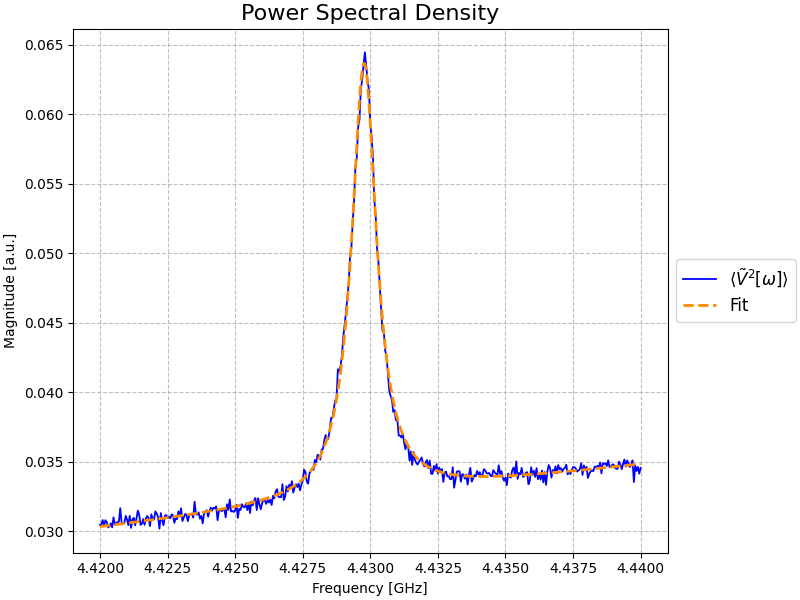

In [ ]:
# GET POWER SPECTRAL DENSITY
PSD_avg, f_arr, t_arr = psd.get_PSD_avg(
    I_all=I_all,
    n_samples=n_samples,
    dt=dt
)

# SELECT BANDWIDTH
PSD_bw, f_bw = psd.get_PSD_bw(
    PSD_avg=PSD_avg,
    f_arr=f_arr,
    f_L=0.39,
    f_R=0.49
)

# Fitting parameters
fit_params = psd.lorentz_fit(
    PSD_bandwidth=PSD_bw,
    f_arr_bandwidth=f_bw,
    lorentzian_fit_func=psd.lorentzian_fit_func,
    verbose=True
)

# PLOT PSD
psd.plot_PSD_bw(
    PSD_bandwidth=PSD_bw,
    f_arr_bandwidth=f_bw,
    fit_params=fit_params,
)